In [1]:
import xarray as xr
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import wasserstein_distance, spearmanr

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report
from scipy.stats import pearsonr
import torch
from torch.utils.data import TensorDataset, DataLoader
from skimage.metrics import structural_similarity as ssim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import CenteredNorm
import numpy.ma as ma

from sklearn.cross_decomposition import PLSRegression
from sklearn.utils import resample

import warnings

In [ ]:
target_res = 0.125
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.5, -60.0, -44.875]
# min_lon_global, min_lat_global, max_lon_gloabl, max_lat_global = [-69.61, -60., -50., -32.45] #bbox of our study
min_time, max_time = pd.to_datetime("2013-01-01"), pd.to_datetime("2023-12-31")

fishing_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp="HKP")
fishing = fishing_ds["cpue_index"]
fishing = fishing.fillna(0)

effort = xr.open_dataset(f"../data/processed/targets/esfuerzo_{target_res}.nc")
effort = effort["Horas"]/24
effort = effort.fillna(0)

mask_ds = xr.open_dataset(f"../data/processed/static/area_pesca_{target_res}.nc")
mask = mask_ds["mask"]
mask = mask.fillna(0)
mask = mask.broadcast_like(fishing)

temp_ds = xr.open_dataset("../data/processed/dynamic/to_surface.nc")
temp = temp_ds["to"]
temp = (temp - temp.mean()) / temp.std()
temp = temp.fillna(0)

temp_bottom_ds = xr.open_dataset("../data/processed/dynamic/temp_bottom.nc")
temp_bottom_ds = temp_bottom_ds.rename({"to": "to_b"})
temp_bottom = temp_bottom_ds["to_b"]
temp_bottom = (temp_bottom - temp_bottom.mean()) / temp_bottom.std()
temp_bottom = temp_bottom.fillna(0)

chl_ds = xr.open_dataset("../data/processed/dynamic/chl.nc")
chl = chl_ds["CHL"]
chl = (chl - chl.mean()) / chl.std()
chl = chl.fillna(0)

mixed_ds = xr.open_dataset("../data/processed/dynamic/mixed_layer.nc")
mixed = mixed_ds["mlotst"]
mixed = (mixed - mixed.mean()) / mixed.std()
mixed = mixed.fillna(0)

depth_ds = xr.open_dataset("../data/processed/static/depth.nc")
depth = depth_ds["depth"] 
depth = (depth - depth.mean()) / depth.std()
depth = depth.fillna(0)
depth = depth.broadcast_like(temp)

zo_ds = xr.open_dataset("../data/processed/dynamic/zo_surface.nc")
zo = zo_ds["zo"]
zo = (zo - zo.mean()) / zo.std()
zo = zo.fillna(0)

so_ds = xr.open_dataset("../data/processed/dynamic/so_surface.nc")
so = so_ds["so"]
so = (so - so.mean()) / so.std()
so = so.fillna(0)

ugo_ds = xr.open_dataset("../data/processed/dynamic/ugo_surface.nc")
ugo = ugo_ds["ugo"]
ugo = (ugo - ugo.mean()) / ugo.std()
ugo = ugo.fillna(0)

vgo_ds = xr.open_dataset("../data/processed/dynamic/vgo_surface.nc")
vgo = vgo_ds["vgo"]
vgo = (vgo - vgo.mean()) / vgo.std()
vgo = vgo.fillna(0)

pp = xr.open_dataset("../data/processed/dynamic/pp.nc")
pp = pp["PP"]
pp = (pp - pp.mean()) / pp.std()
pp = pp.fillna(0)

cdm = xr.open_dataset("../data/processed/dynamic/cdm.nc")
cdm = cdm["CDM"]
cdm = (cdm - cdm.mean()) / cdm.std()
cdm = cdm.fillna(0)

spm = xr.open_dataset("../data/processed/dynamic/spm.nc")
spm = spm["SPM"]
spm = (spm - spm.mean()) / spm.std()    
spm = spm.fillna(0)

zsd = xr.open_dataset("../data/processed/dynamic/zsd.nc")
zsd = zsd["ZSD"]
zsd = (zsd - zsd.mean()) / zsd.std()
zsd = zsd.fillna(0)


month = temp["time"].dt.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin = month_sin.broadcast_like(temp)
month_cos = month_cos.broadcast_like(temp)
month_sin.name = "month_sin"
month_cos.name = "month_cos"
month = month.broadcast_like(temp)

year = temp["time"].dt.year
year = (year - year.mean()) / year.std()
year = year.broadcast_like(temp)

lat = (temp["lat"] - temp["lat"].mean()) / temp["lat"].std()
lon = (temp["lon"] - temp["lon"].mean()) / temp["lon"].std()
lat = lat.broadcast_like(temp)
lon = lon.broadcast_like(temp)

temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, ugo, vgo, pp, cdm, spm, zsd = xr.align(
    temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, vgo, ugo, pp, cdm, spm, zsd, join="inner")

fishing, effort, mask = xr.align(fishing, effort, mask, join="inner")


#area de pesca y un poco alrededor
croppedT = lambda da: da.sel(
    lon=slice(min_lon-0.5, max_lon+0.5),
    lat=slice(min_lat-0.5, max_lat+0.5),
    time=slice(min_time, max_time)
)

# area global
cropped = lambda da: da.sel(
    lon=slice(min_lon-0.5, max_lon+2),
    lat=slice(min_lat-4, max_lat+1),
    time=slice(min_time, max_time)
)

fishing = croppedT(fishing)
effortT = croppedT(effort)    
mask = croppedT(mask)

effortV = cropped(effort)
temp = cropped(temp)
temp_bottom = cropped(temp_bottom)
chl = cropped(chl)
mixed = cropped(mixed)
depth = cropped(depth)
zo = cropped(zo)
so = cropped(so)
month = cropped(month)
month_sin = cropped(month_sin)
month_cos = cropped(month_cos)
lat = cropped(lat)
lon = cropped(lon)
year = cropped(year)
ugo = cropped(ugo)
vgo = cropped(vgo)
pp = cropped(pp)
cdm = cropped(cdm)
spm = cropped(spm)
zsd = cropped(zsd)

In [3]:
y = fishing
y = y.transpose("time", "lat", "lon")

m = mask 
m = m.transpose("time", "lat", "lon")


vars_ = [temp, so, mixed, zo, temp_bottom,  
        ugo, vgo, chl, cdm, pp,
        month_sin, month_cos,
        # lat, lon,
        # depth,
        ]

vars_names = [v.name for v in vars_]
in_channels = len(vars_)
X = xr.concat(vars_, dim="channel")
X = X.transpose("time", "channel", "lat", "lon")
print(X.shape)
print(y.shape)
print(m.shape)

split_year = 2020

train_X = X.sel(time=slice(None, f"{split_year-1}-12-31"))
test_X  = X.sel(time=slice(f"{split_year}-01-01", None))

train_y = y.sel(time=slice(None, f"{split_year-1}-12-31"))
test_y  = y.sel(time=slice(f"{split_year}-01-01", None))

m_train = m.sel(time=slice(None, f"{split_year-1}-12-31"))
m_test  = m.sel(time=slice(f"{split_year}-01-01", None))


# -------- Check inflation factor --------
X_np = train_X.values  # (time, channel, lat, lon)
t, c, h, w = X_np.shape
X_flat = X_np.reshape(t, c, -1)       # (time, channel, pixels)
X_flat = X_flat.transpose(0, 2, 1)    # (time, pixels, channel)
X_flat = X_flat.reshape(-1, c)        # (samples, channel)
df = pd.DataFrame(X_flat, columns=vars_names)
vif_data = pd.DataFrame()
vif_data["feature"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i)for i in range(df.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))

def create_windows(X, y, m, window=12):
    X_data = X.values   # (time, channels, H, W)
    y_data = y.values   # (time, H, W)
    m_data = m.values   # (time, H, W)

    X_seq, y_seq, m_seq= [], [], []

    for i in range(len(X_data) - window):
        X_seq.append(X_data[i:i+window]) #12 months
        y_seq.append(y_data[i+window]) #next month
        m_seq.append(m_data[i+window]) #next month
        

    return (
        torch.tensor(np.stack(X_seq), dtype=torch.float32),
        torch.tensor(np.stack(y_seq), dtype=torch.float32),
        torch.tensor(np.stack(m_seq), dtype=torch.float32),
    )

window = 12 #12 months

X_train, y_train, m_train = create_windows(train_X, train_y, m_train, window)
X_test, y_test, m_test = create_windows(test_X, test_y, m_test, window)

print(X_train.shape)  # (N, T, C, H, W)
print(y_train.shape)  # (N, H, W)
print(m_train.shape)  # (N, H, W)
###### Data Loaders ######
batch_size = 24

train_loader = DataLoader(
    TensorDataset(X_train, y_train, m_train),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test, m_test),
    batch_size=batch_size,
    shuffle=False
)


(132, 12, 62, 28)
(132, 30, 16)
(132, 30, 16)
   feature        VIF
1       so  96.037970
0       to  77.739747
4     to_b  51.768263
9       PP  38.800210
7      CHL  16.137885
3       zo  13.849659
2   mlotst   8.625184
8      CDM   4.980552
11   month   4.373258
5      vgo   4.013116
10   month   3.715053
6      ugo   1.414546
torch.Size([72, 12, 12, 62, 28])
torch.Size([72, 30, 16])
torch.Size([72, 30, 16])


In [4]:
def prep_rf_data(X, y, m=None):
    """
    Converts 5D input tensors and 3D target tensors into 2D arrays 
    compatible with scikit-learn Random Forest. Handles both Torch tensors and Numpy arrays.
    """
    # Move to CPU and convert to numpy if dealing with PyTorch Tensors
    if isinstance(X, torch.Tensor):
        X = X.detach().cpu().numpy()
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu().numpy()
    if isinstance(m, torch.Tensor):
        m = m.detach().cpu().numpy()

    N = X.shape[0]
    
    # Flatten features: (N, T, C, H_x, W_x) -> (N, T * C * H_x * W_x)
    # For your train data: (72, 12, 11, 94, 48) -> (72, 595584)
    X_rf = X.reshape(N, -1)
    
    # Flatten targets: (N, H_y, W_y) -> (N, H_y * W_y)
    # For your train data: (72, 37, 20) -> (72, 740)
    y_rf = y.reshape(N, -1)
    
    if m is not None:
        m_rf = m.reshape(N, -1)
        return X_rf, y_rf, m_rf
    else:
        return X_rf, y_rf

X_train_ml, y_train_ml, m_train_ml = prep_rf_data(X_train, y_train, m_train)
X_test_ml, y_test_ml, m_test_ml = prep_rf_data(X_test, y_test, m_test)

H_out_test, W_out_test = y_test.shape[1], y_test.shape[2]

m_true = m_test_ml.reshape(-1, H_out_test, W_out_test)
y_true = y_test_ml.reshape(-1, H_out_test, W_out_test)

mask_flat = m_test_ml.astype(bool)


In [5]:
def compute_metrics(y_test_ml, y_pred_flat, y_true, mask_spatial):

    # =====================================================
    # 1. FLATTEN FOR METRICS
    # =====================================================
    y_test_flat = y_test_ml.flatten()
    y_pred_flat = y_pred_flat.flatten()
    
    mask_spatial = mask_spatial.astype(bool)
    mask_flat = mask_spatial.flatten().astype(bool)
    

    y_test_masked = y_test_flat[mask_flat]
    y_pred_masked = y_pred_flat[mask_flat]

    # =====================================================
    # 2. REGRESSION METRICS
    # =====================================================
    rmse = np.sqrt(mean_squared_error(y_test_masked, y_pred_masked))
    mae = mean_absolute_error(y_test_masked, y_pred_masked)
    r2 = r2_score(y_test_masked, y_pred_masked)
    pearson_corr = pearsonr(y_test_masked, y_pred_masked)[0]
    mbe = np.mean(y_pred_masked - y_test_masked)
    data_range_flat = np.max(y_test_masked) - np.min(y_test_masked)
    nrmse = rmse / data_range_flat

    w_dist = wasserstein_distance(y_test_masked, y_pred_masked)
    spearman_corr, p_val = spearmanr(y_test_masked, y_pred_masked)

    print("RMSE:", f"{rmse:.4f}")
    print(f"Normalized RMSE: {nrmse:.4f} ({nrmse*100:.2f}%)")
    print("MAE:", f"{mae:.4f}")
    print("R2:", f"{r2:.4f}")
    print("Pearson R:", f"{pearson_corr:.4f}")
    print("MBE:", f"{mbe:.4f}")
    print(f"Wasserstein Distance: {w_dist:.4f}")
    print(f"Spearman Rank Correlation: {spearman_corr:.2f}")

    # =====================================================
    # HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    hotspot_threshold_true = np.percentile(y_test_masked, percentile)
    hotspot_threshold_pred = np.percentile(y_pred_masked, percentile)

    # Create boolean masks for the top 20%
    actual_hotspots = (y_test_masked >= hotspot_threshold_true)
    pred_hotspots = (y_pred_masked >= hotspot_threshold_pred)

    # Count how many points are in the true top 20%
    total_actual_hotspots = np.sum(actual_hotspots)

    # Count how many points are in BOTH the true top 20% AND predicted top 20%
    shared_hotspots = np.sum(actual_hotspots & pred_hotspots)

    # Calculate the Hit Rate percentage
    hit_rate = shared_hotspots / total_actual_hotspots
    hit_rate_percent = hit_rate * 100

    print(f"\n--- Total hotspot Hit Rate (Top {100-percentile}% Overlap) ---")
    print(f"Total True Hotspots             : {total_actual_hotspots}")
    print(f"Correctly Predicted Hotspots    : {shared_hotspots}")
    print(f"Hit Rate                        : {hit_rate_percent:.4f}%")
    print(f"-------------------------------------------------\n")
    
    # =====================================================
    # MONTHLY HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    
    # Rebuild 3D shape to iterate over time (months)
    H_out, W_out = y_true.shape[1], y_true.shape[2]
    y_pred3D_temp = y_pred_flat.reshape(-1, H_out, W_out)
    
    total_actual_hotspots_all = 0
    shared_hotspots_all = 0
    monthly_hit_rates = []
    
    # Iterate through each month (time step)
    for i in range(y_true.shape[0]):
        
        # Handle the spatial mask safely (whether it is 2D or 3D)
        current_mask = mask_spatial[i] if mask_spatial.ndim == 3 else mask_spatial
        
        # Extract valid pixels strictly for this month
        y_true_month = y_true[i][current_mask]
        y_pred_month = y_pred3D_temp[i][current_mask]
        
        # Skip if mask leaves no valid pixels for this month
        if len(y_true_month) == 0:
            continue
            
        # Calculate the 80th percentile threshold for THIS specific month
        thresh_true = np.percentile(y_true_month, percentile)
        thresh_pred = np.percentile(y_pred_month, percentile)
        
        # Create boolean masks for the top 20%
        actual_hotspots_month = (y_true_month >= thresh_true)
        pred_hotspots_month = (y_pred_month >= thresh_pred)
        
        # Count overlaps
        total_actual = np.sum(actual_hotspots_month)
        shared = np.sum(actual_hotspots_month & pred_hotspots_month)
        
        # Keep running totals for the aggregate score
        total_actual_hotspots_all += total_actual
        shared_hotspots_all += shared
        
        # Calculate hit rate strictly for this month
        if total_actual > 0:
            monthly_hit_rates.append((shared / total_actual) * 100)

    # Calculate final aggregate metrics across all months
    mean_monthly_hit_rate = np.mean(monthly_hit_rates)
    aggregate_hit_rate = (shared_hotspots_all / total_actual_hotspots_all) * 100 if total_actual_hotspots_all > 0 else 0
    print(f"\n------- Monthly Hotspot Hit Rate (Top {100-percentile}% Overlap) ------")
    print(f"Total True Hotspots (All Months)    : {total_actual_hotspots_all}")
    print(f"Correctly Predicted (All Months)    : {shared_hotspots_all}")
    print(f"Mean Monthly Hit Rate               : {mean_monthly_hit_rate:.3f}%")
    print(f"Aggregate Hit Rate                  : {aggregate_hit_rate:.3f}%")
    print(f"-------------------------------------------------\n")

    # =====================================================
    # Reshape to 3D
    # =====================================================
    H_out, W_out = y_true.shape[1], y_true.shape[2]
    y_pred3D = y_pred_flat.reshape(-1, H_out, W_out)
    mask_spatial = mask_spatial.astype(bool)

    # =====================================================
    # SSIM
    # =====================================================
    data_range = (y_true[mask_spatial].max()-y_true[mask_spatial].min())

    ssim_scores = []

    for i in range(y_true.shape[0]):

        _, ssim_map = ssim(
            y_true[i],
            y_pred3D[i],
            data_range=data_range,
            win_size=5,
            full=True
        )

        valid_ssim_pixels = ssim_map[mask_spatial[i]]

        if len(valid_ssim_pixels) > 0:
            ssim_scores.append(np.mean(valid_ssim_pixels))

    mean_ssim = np.mean(ssim_scores)

    print(f"Mean Masked SSIM: {mean_ssim:.4f}\n")

    # =====================================================
    # PLOTTING
    # =====================================================

    y_true_m = np.where(mask_spatial, y_true, 0)
    y_pred_m = np.where(mask_spatial, y_pred3D, 0)

    # 2. Compute means. The masked array automatically ignores the hidden values!
    y_pred_mean = y_pred_m.mean(axis=0)
    y_true_mean = y_true_m.mean(axis=0)
 
    error = y_pred_mean - y_true_mean

    plt.figure(figsize=(12, 4))

    ax1 = plt.subplot(1, 3, 1)
    plt.title("Mean Test Truth")
    plt.imshow(y_true_mean, cmap='viridis') 
    plt.colorbar()
    ax1.invert_yaxis()

    ax2 = plt.subplot(1, 3, 2)
    plt.title("Mean Test Prediction")
    plt.imshow(y_pred_mean, cmap='viridis')
    plt.colorbar()
    ax2.invert_yaxis()

    ax3 = plt.subplot(1, 3, 3)
    plt.title("Mean Error (Pred - True)")
    
    plt.imshow(error, cmap='coolwarm', norm=CenteredNorm())
    plt.colorbar()
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Time Series Plot
    # -----------------------------------------------------
    y_true_m2 = ma.masked_where(~mask_spatial, y_true)
    y_pred_m2 = ma.masked_where(~mask_spatial, y_pred3D)
    y_pred_plot2 = y_pred_m2.mean(axis=(1, 2))
    y_true_plot2 = y_true_m2.mean(axis=(1, 2))
    
    r2_plot2 = r2_score(y_true_plot2, y_pred_plot2)

    plt.figure(figsize=(12, 4))
    plt.plot(y_true_plot2, label="True")
    plt.plot(y_pred_plot2, label="Predicted")
    plt.annotate(f"Best Test R2: {r2_plot2:.3f}", xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom')
    plt.xlabel("Time (Months)")
    plt.title("Time Series Comparison")
    plt.legend()
    plt.show()

RMSE: 1.8341
Normalized RMSE: 0.1438 (14.38%)
MAE: 1.2782
R2: 0.5173
Pearson R: 0.7280
MBE: -0.2587
Wasserstein Distance: 0.8877
Spearman Rank Correlation: 0.70

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Total True Hotspots             : 893
Correctly Predicted Hotspots    : 510
Hit Rate                        : 57.1109%
-------------------------------------------------


------- Monthly Hotspot Hit Rate (Top 20% Overlap) ------
Total True Hotspots (All Months)    : 1292
Correctly Predicted (All Months)    : 459
Mean Monthly Hit Rate               : 42.412%
Aggregate Hit Rate                  : 35.526%
-------------------------------------------------

Mean Masked SSIM: 0.5308



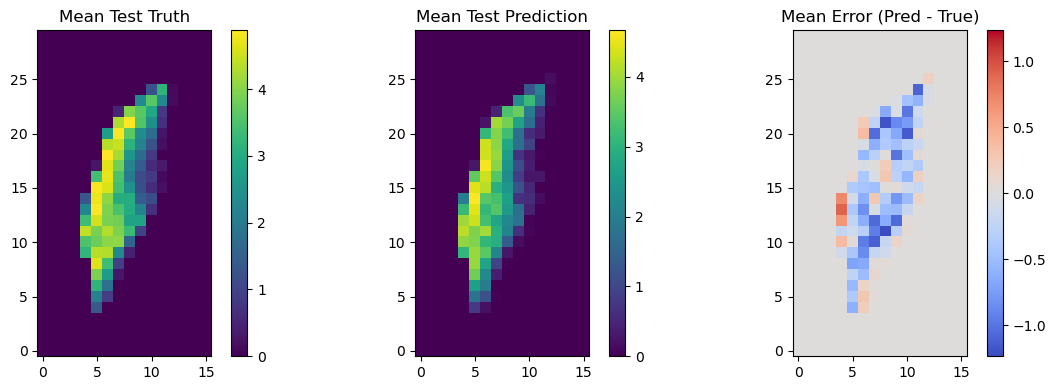

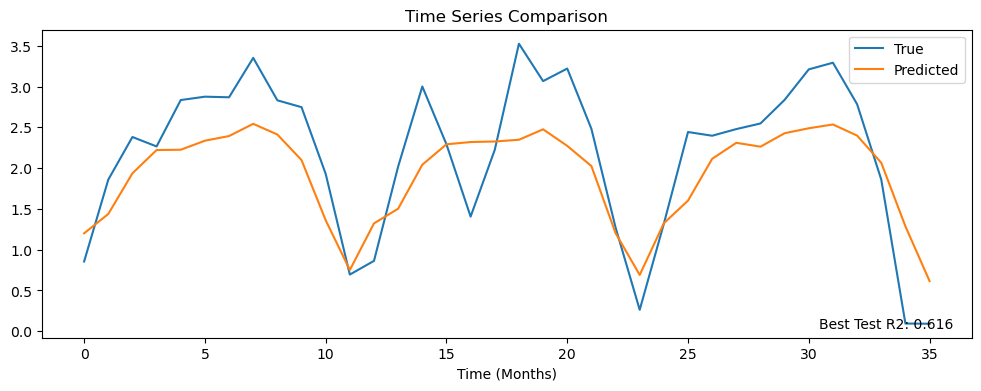

   Variable  Importance
0        PP    0.150747
1        to    0.138719
2    mlotst    0.120285
3      to_b    0.086682
4       CDM    0.083116
5        zo    0.081807
6       CHL    0.080174
7        so    0.070976
8       vgo    0.069940
9       ugo    0.068634
10    month    0.024484
11    month    0.024437


In [6]:
model = RandomForestRegressor(n_estimators=100, max_features="sqrt", n_jobs=-1, random_state=42)
model.fit(X_train_ml, y_train_ml)

y_pred_flat = model.predict(X_test_ml)

compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)

# -------- Feature Importance Extraction --------
raw_importances = model.feature_importances_
T = X_train.shape[1]   # window (12)
C = X_train.shape[2]   # number of variables/channels
H_x = X_train.shape[3] # height (lat)
W_x = X_train.shape[4] # width (lon)

reshaped_importances = raw_importances.reshape(T, C, H_x, W_x)

variable_importances = reshaped_importances.sum(axis=(0, 2, 3))


importance_df = pd.DataFrame({
    'Variable': vars_names,
    'Importance': variable_importances
})

# Sort in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
print(importance_df)

RMSE: 1.8387
Normalized RMSE: 0.1441 (14.41%)
MAE: 1.2596
R2: 0.5149
Pearson R: 0.7249
MBE: -0.2546
Wasserstein Distance: 0.8355
Spearman Rank Correlation: 0.70

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Total True Hotspots             : 893
Correctly Predicted Hotspots    : 504
Hit Rate                        : 56.4390%
-------------------------------------------------


------- Monthly Hotspot Hit Rate (Top 20% Overlap) ------
Total True Hotspots (All Months)    : 1292
Correctly Predicted (All Months)    : 466
Mean Monthly Hit Rate               : 43.189%
Aggregate Hit Rate                  : 36.068%
-------------------------------------------------

Mean Masked SSIM: 0.5324



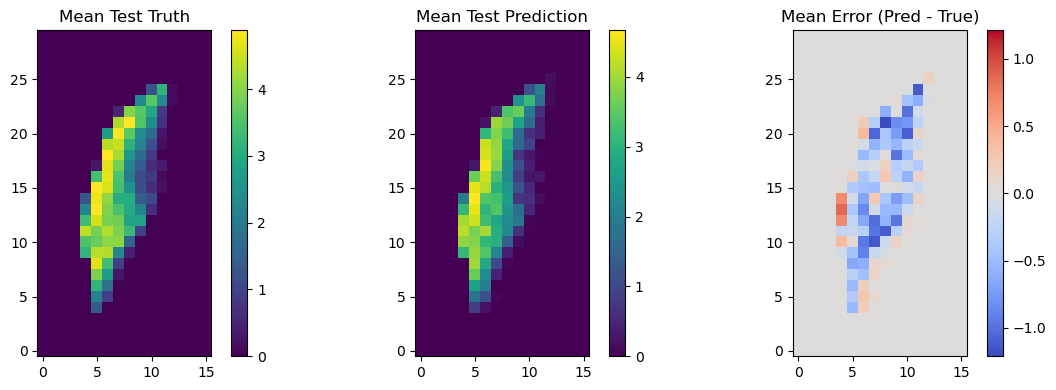

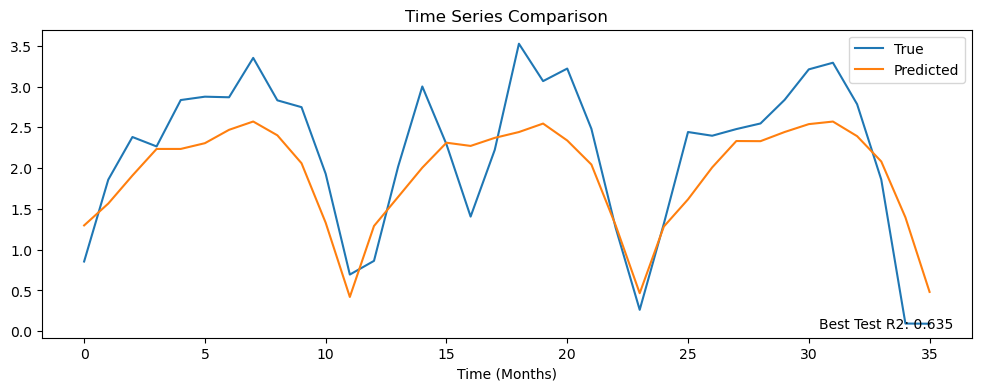

In [7]:
model = ExtraTreesRegressor(n_estimators=500, max_features="sqrt", n_jobs=-1, random_state=42)
model.fit(X_train_ml, y_train_ml)

y_pred_flat = model.predict(X_test_ml)

compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)

c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


RMSE: 1.8609
Normalized RMSE: 0.1459 (14.59%)
MAE: 1.2795
R2: 0.5031
Pearson R: 0.7189
MBE: -0.2944
Wasserstein Distance: 0.8663
Spearman Rank Correlation: 0.69

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Total True Hotspots             : 893
Correctly Predicted Hotspots    : 502
Hit Rate                        : 56.2150%
-------------------------------------------------


------- Monthly Hotspot Hit Rate (Top 20% Overlap) ------
Total True Hotspots (All Months)    : 1292
Correctly Predicted (All Months)    : 463
Mean Monthly Hit Rate               : 42.856%
Aggregate Hit Rate                  : 35.836%
-------------------------------------------------

Mean Masked SSIM: 0.5214



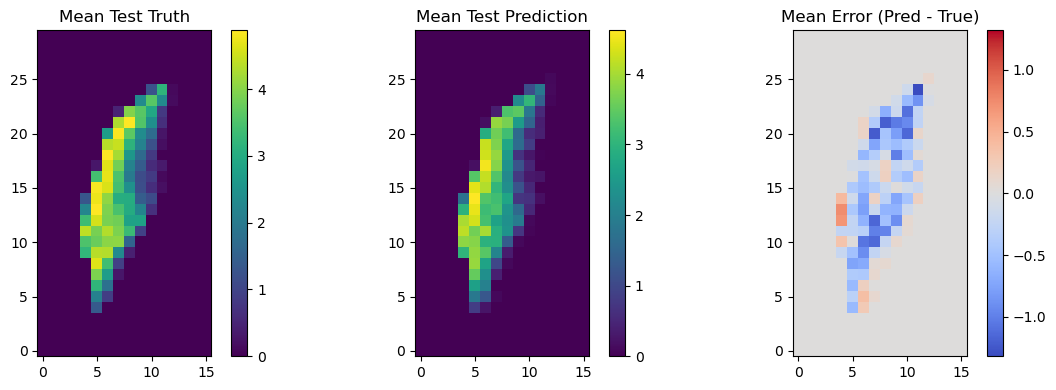

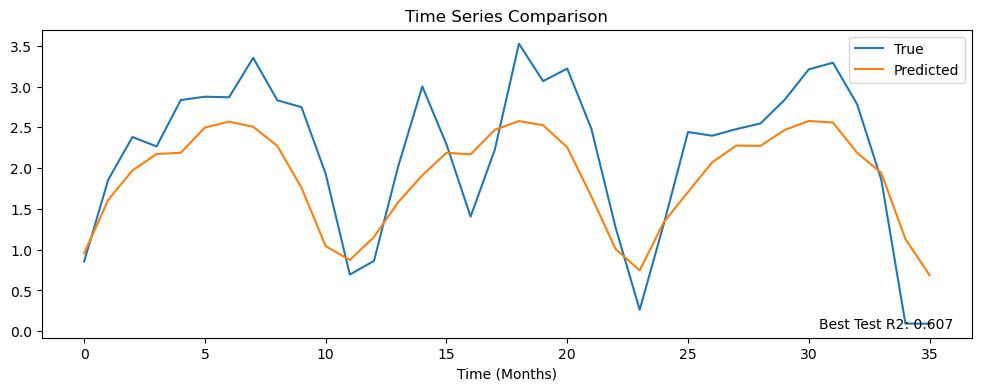

In [8]:
model = KNeighborsRegressor(n_neighbors=10, weights='distance', n_jobs=-1)
model.fit(X_train_ml, y_train_ml)

y_pred_flat = model.predict(X_test_ml)
compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)



RMSE: 1.9984
Normalized RMSE: 0.1566 (15.66%)
MAE: 1.3900
R2: 0.4270
Pearson R: 0.6618
MBE: -0.1523
Wasserstein Distance: 0.8298
Spearman Rank Correlation: 0.65

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Total True Hotspots             : 893
Correctly Predicted Hotspots    : 439
Hit Rate                        : 49.1601%
-------------------------------------------------


------- Monthly Hotspot Hit Rate (Top 20% Overlap) ------
Total True Hotspots (All Months)    : 1292
Correctly Predicted (All Months)    : 435
Mean Monthly Hit Rate               : 39.745%
Aggregate Hit Rate                  : 33.669%
-------------------------------------------------

Mean Masked SSIM: 0.5035



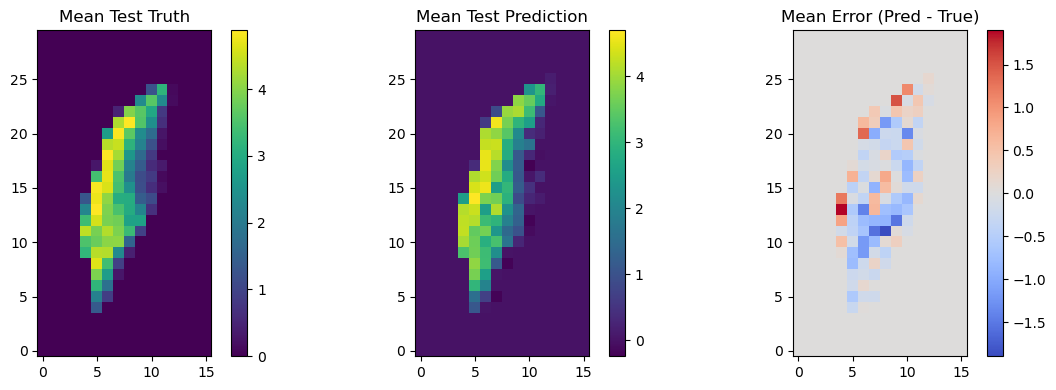

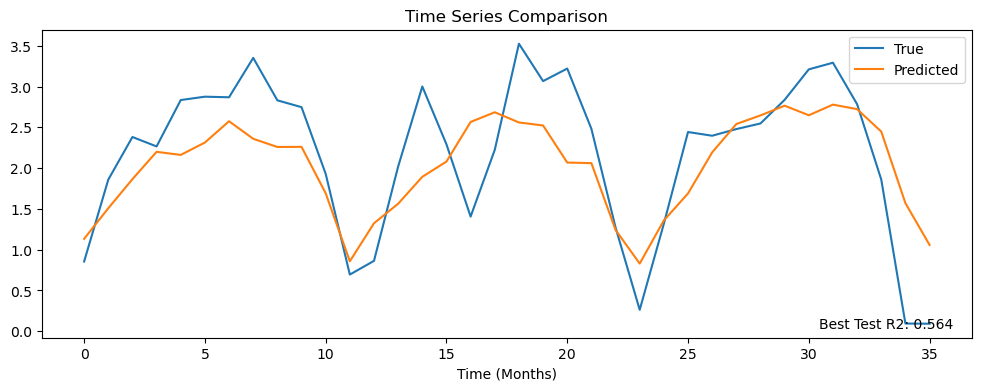

   Variable  Overall_Impact     Direction
6       ugo        4.177469  Positive (+)
8       CDM        3.967108  Positive (+)
3        zo        2.353061  Positive (+)
5       vgo        2.298681  Negative (-)
1        so        0.880884  Negative (-)
4      to_b        0.559664  Positive (+)
7       CHL        0.161179  Positive (+)
11    month        0.049339  Positive (+)
10    month        0.049339  Positive (+)
0        to        0.017069  Positive (+)
2    mlotst        0.004801  Positive (+)
9        PP        0.000120  Positive (+)


In [9]:
n_comp = 10
model = PLSRegression(n_components=n_comp)
model.fit(X_train_ml, y_train_ml)
y_pred_flat = model.predict(X_test_ml)

compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)

# -------- Advanced Statistical Feature Extraction --------

# Get the original shapes from your raw 5D X_train tensor
T = X_train.shape[1]   # 12 months
C = X_train.shape[2]   # variables/channels
H_x = X_train.shape[3] # latitude grid
W_x = X_train.shape[4] # longitude grid

raw_coefficients = model.coef_.mean(axis=0) 


reshaped_coefs = raw_coefficients.reshape(T, C, H_x, W_x)

global_weights = np.abs(reshaped_coefs).sum(axis=(0, 2, 3))
global_direction = np.sign(reshaped_coefs.mean(axis=(0, 2, 3)))

direction_labels = ['Positive (+)' if d > 0 else 'Negative (-)' for d in global_direction]

importance_df = pd.DataFrame({
    'Variable': vars_names,
    'Overall_Impact': global_weights,
    'Direction': direction_labels
})
print(importance_df.sort_values(by='Overall_Impact', ascending=False))



c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\sklearn\linear_model\_ridge.py:252: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


RMSE: 2.1771
Normalized RMSE: 0.1707 (17.07%)
MAE: 1.4967
R2: 0.3200
Pearson R: 0.6244
MBE: -0.1535
Wasserstein Distance: 0.7042
Spearman Rank Correlation: 0.61

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Total True Hotspots             : 893
Correctly Predicted Hotspots    : 481
Hit Rate                        : 53.8634%
-------------------------------------------------


------- Monthly Hotspot Hit Rate (Top 20% Overlap) ------
Total True Hotspots (All Months)    : 1292
Correctly Predicted (All Months)    : 422
Mean Monthly Hit Rate               : 38.300%
Aggregate Hit Rate                  : 32.663%
-------------------------------------------------

Mean Masked SSIM: 0.4528



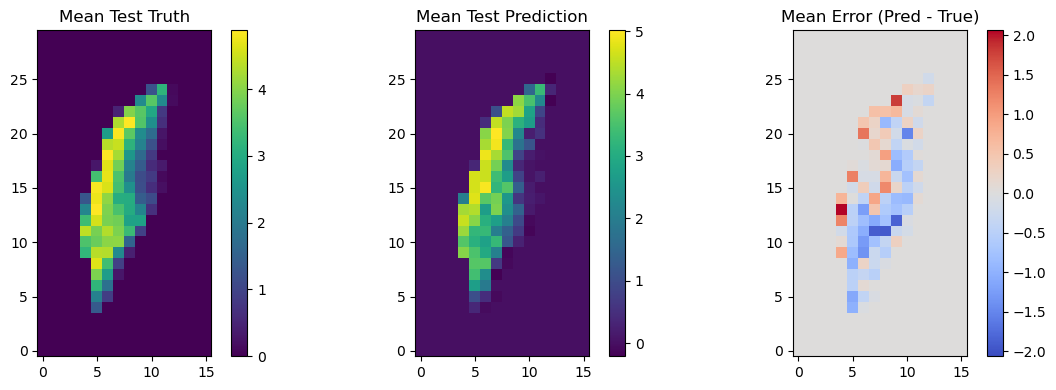

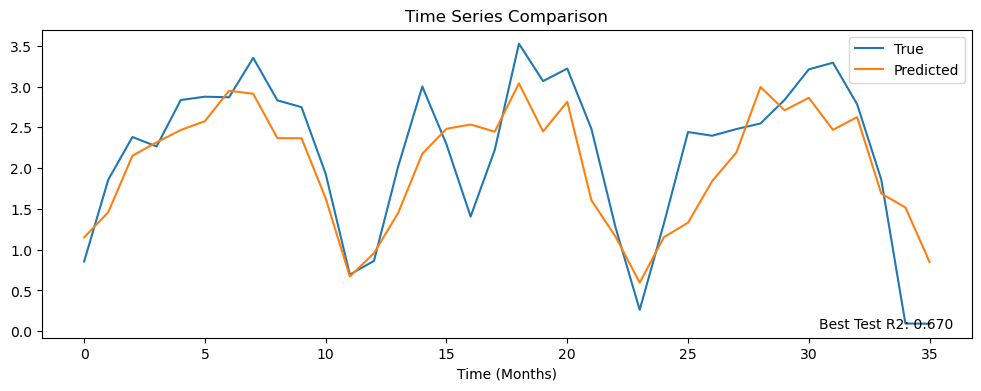

Running 50 bootstrap iterations

--- Ridge (L2) Bootstrapped Significance Report ---
   Variable  Significant_Grid_Ratio  Overall_Impact     Direction
10    month                0.333333    1.705034e-06  Negative (-)
11    month                0.333333    1.705034e-06  Negative (-)
0        to                0.251632    1.136392e-05  Positive (+)
8       CDM                0.195084    4.143901e-07  Negative (-)
2    mlotst                0.184956    2.505200e-04  Negative (-)
9        PP                0.157930    3.181449e-03  Positive (+)
4      to_b                0.154618    5.446375e-06  Positive (+)
7       CHL                0.148137    8.782015e-06  Negative (-)
5       vgo                0.125384    7.301720e-07  Negative (-)
6       ugo                0.108199    4.136261e-07  Positive (+)
3        zo                0.080693    4.689402e-07  Positive (+)
1        so                0.017089    9.696172e-07  Negative (-)


In [10]:
# 1. Fit standard Ridge Regression on the full training dataset
ridge_model = Ridge(alpha=1.0, solver='auto', random_state=42)
ridge_model.fit(X_train_ml, y_train_ml)

# 2. Predict and evaluate using your standard pipeline
y_pred_flat = ridge_model.predict(X_test_ml)
compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)

# -------- Bootstrapping for Statistical metrics --------
warnings.filterwarnings("ignore", message="Singular matrix in solving dual problem") # Suppress the specific warning 

n_iterations = 50  
n_features = X_train_ml.shape[1]
bootstrapped_coefs = np.zeros((n_iterations, n_features), dtype=np.float32)

print(f"Running {n_iterations} bootstrap iterations")

for i in range(n_iterations):
    X_boot, y_boot = resample(X_train_ml, y_train_ml, random_state=i)
    boot_model = Ridge(alpha=1.0, solver='auto', random_state=i)
    boot_model.fit(X_boot, y_boot)
    bootstrapped_coefs[i, :] = boot_model.coef_.mean(axis=0)

# -------- Advanced Statistical Feature Extraction (Confidence Intervals) --------

# Calculate the 2.5th and 97.5th percentiles to build a 95% Confidence Interval
# This acts as our mathematical surrogate for a two-tailed p < 0.05 threshold
lower_bound = np.percentile(bootstrapped_coefs, 2.5, axis=0)
upper_bound = np.percentile(bootstrapped_coefs, 97.5, axis=0)

# A feature is statistically stable/significant if its 95% CI does not cross zero
# (meaning it is strictly positive or strictly negative across 95% of resamples)
is_significant = (lower_bound > 0) | (upper_bound < 0)

# -------- Reshaping & Grid Aggregation --------

# Extract and average coefficients from your baseline full-dataset model
raw_ridge_coefs = ridge_model.coef_.mean(axis=0)

# Reshape both baseline weights and the significance mask back to the 5D spatiotemporal grid
reshaped_ridge_coefs = raw_ridge_coefs.reshape(T, C, H_x, W_x)
reshaped_significance = is_significant.reshape(T, C, H_x, W_x)

# Calculate final aggregated metrics across dimensions (T, H_x, W_x)
# Significant_Grid_Ratio: % of the spatiotemporal domain where the variable is significant
significant_grid_ratio = reshaped_significance.mean(axis=(0, 2, 3))
global_ridge_weights = np.abs(reshaped_ridge_coefs).sum(axis=(0, 2, 3))
global_ridge_direction = np.sign(reshaped_ridge_coefs.mean(axis=(0, 2, 3)))

direction_labels = ['Positive (+)' if d > 0 else 'Negative (-)' for d in global_ridge_direction]

# Compile the final statistical report
ridge_importance_df = pd.DataFrame({
    'Variable': vars_names,
    'Significant_Grid_Ratio': significant_grid_ratio,
    'Overall_Impact': global_ridge_weights,
    'Direction': direction_labels
})

print("\n--- Ridge (L2) Bootstrapped Significance Report ---")
print(ridge_importance_df.sort_values(by='Significant_Grid_Ratio', ascending=False))

RMSE: 2.0307
Normalized RMSE: 0.1592 (15.92%)
MAE: 1.3902
R2: 0.4083
Pearson R: 0.6618
MBE: -0.1539
Wasserstein Distance: 0.7186
Spearman Rank Correlation: 0.64

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Total True Hotspots             : 893
Correctly Predicted Hotspots    : 492
Hit Rate                        : 55.0952%
-------------------------------------------------


------- Monthly Hotspot Hit Rate (Top 20% Overlap) ------
Total True Hotspots (All Months)    : 1292
Correctly Predicted (All Months)    : 414
Mean Monthly Hit Rate               : 37.412%
Aggregate Hit Rate                  : 32.043%
-------------------------------------------------

Mean Masked SSIM: 0.4857



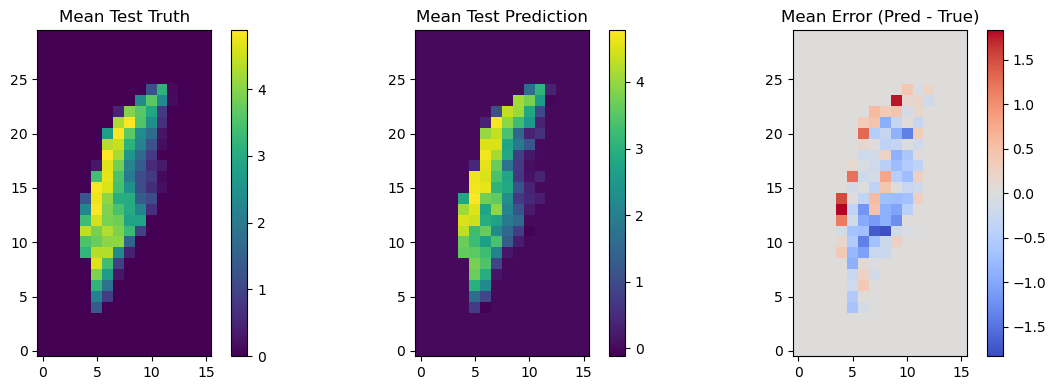

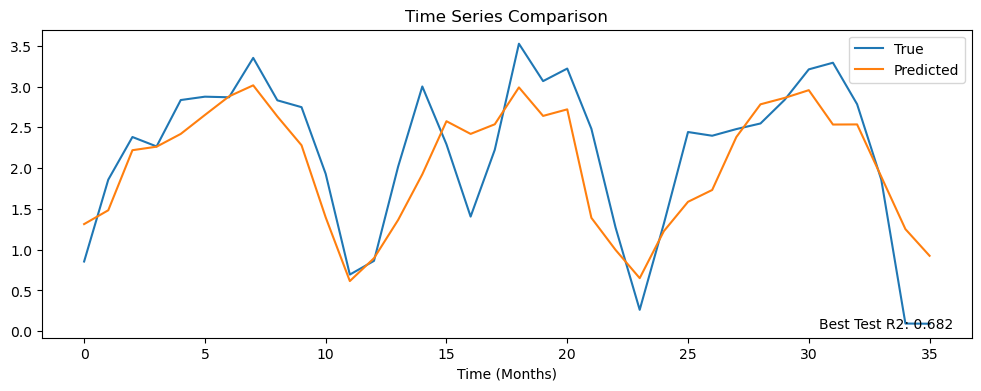

In [11]:
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train_ml)
X_test_pca = pca.transform(X_test_ml)

model = Ridge()
model.fit(X_train_pca, y_train_ml)

y_pred_flat = model.predict(X_test_pca)
compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)